# Phase 2 — Deep Leakage from Gradients (DLG)

**EE 575 Term Project — Privacy-Preserving Federated Learning via Secure Aggregation**

This notebook demonstrates that the gradients sent in vanilla federated learning are *not* private. By running the DLG attack of Zhu, Liu, and Han (NeurIPS 2019), we show that an honest-but-curious server can reconstruct a client's private input using nothing but the gradient that client uploaded.

## What we will do

1. Load the FedAvg model trained in Phase 1 (the system we are about to attack).
2. Pick one MNIST image from a simulated client. This is the "private" input the attacker wants.
3. Compute the gradient that an honest client would send to the server.
4. Run the DLG attack: starting from random noise, iteratively reconstruct the input by matching gradients.
5. Visualize the reconstruction at iterations 0, 10, 50, 100, 200, 300 — mirroring Figure 3 of the DLG paper.
6. Quantify the attack with PSNR and SSIM and log results.

## Why this is the project's pivotal demo

The visual sequence — random noise on the left, the original digit on the right, and the same digit emerging in between — is the strongest argument for why Secure Aggregation is necessary. We will reuse this exact pattern in Phase 3 to show that *with* Secure Aggregation, the same attack only ever sees noise.

## 1. Setup

In [16]:
import sys
from pathlib import Path

# Robust project-root discovery — works no matter where the kernel started.
_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / "requirements.txt").exists() and (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: .


In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_mnist_federated
from src.model import MNIST_CNN
from src.dlg_attack import (
    compute_victim_gradient,
    dlg_attack,
    reconstruction_metrics,
    denormalize_mnist,
)

# IMPORTANT: We force CPU here even on Apple Silicon. The attack relies on
# create_graph=True for second-derivative computation, and PyTorch's MPS
# backend has incomplete support for double-backprop on some operators.
# CPU is reliable and the model is small enough that speed is not an issue
# (one full attack runs in ~30 seconds on an M1).
DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cpu


## 2. Load the Phase 1 trained model

We attack a *trained* model rather than randomly-initialized weights because the threat is most realistic mid-training: by the time training has progressed for a while, gradients carry rich, attackable information about the local data. The DLG paper notes that attacks succeed even on untrained models, but the trained-model setting matches the threat model in real federated systems most directly.

In [18]:
model = MNIST_CNN().to(DEVICE)
phase1_state_path = RESULTS_DIR / "phase1_final_state.pt"

if phase1_state_path.exists():
    state = torch.load(phase1_state_path, map_location=DEVICE)
    model.load_state_dict(state)
    print(f"Loaded Phase 1 trained weights from {phase1_state_path}")
else:
    print("WARNING: Phase 1 weights not found. Using random initialization.")
    print("  Run experiments/01_baseline_fl.ipynb first for the realistic setting.")

model.eval()
print(f"Model ready on {DEVICE}")

Loaded Phase 1 trained weights from ./results/phase1_final_state.pt
Model ready on cpu


## 3. Pick a victim sample

We grab one image from a simulated client's local data. In a real scenario this is a private text message, medical image, or photo — here it is just an MNIST digit, but the attack mechanics are identical.

Victim input shape : (1, 1, 28, 28)
Victim label       : 8


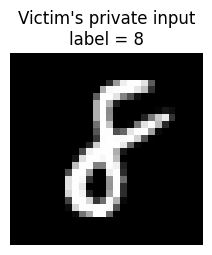

In [19]:
split = load_mnist_federated(num_clients=5, batch_size=32, iid=True, seed=SEED)

# Pull the first sample from client 0's local dataset.
victim_dataset = split.client_loaders[0].dataset
victim_x_raw, victim_y_int = victim_dataset[0]   # tensor (1,28,28), int label
victim_x = victim_x_raw.unsqueeze(0).to(DEVICE)  # add batch dim -> (1,1,28,28)

print(f"Victim input shape : {tuple(victim_x.shape)}")
print(f"Victim label       : {victim_y_int}")

# Show the victim image — this is what the attacker should NOT see.
plt.figure(figsize=(2.5, 2.5))
plt.imshow(denormalize_mnist(victim_x).squeeze().cpu().numpy(), cmap="gray")
plt.title(f"Victim's private input\nlabel = {victim_y_int}")
plt.axis("off")
plt.show()

## 4. Compute the victim's gradient

This is exactly what an honest client would compute and upload to the server in vanilla FL. The attacker (server) gets to keep this vector.

In [20]:
target_grads = compute_victim_gradient(
    model=model,
    x=victim_x,
    y_index=int(victim_y_int),
    num_classes=10,
)

# Quick sanity check — print the shape of each gradient tensor.
total_params = sum(g.numel() for g in target_grads)
print(f"Number of gradient tensors: {len(target_grads)}")
print(f"Total scalar values      : {total_params:,}")
print(f"Per-layer shapes         : {[tuple(g.shape) for g in target_grads]}")

Number of gradient tensors: 6
Total scalar values      : 9,814
Per-layer shapes         : [(12, 1, 5, 5), (12,), (12, 12, 5, 5), (12,), (10, 588), (10,)]


Notice the size: a few thousand floating-point numbers. This is what the FL community used to consider "safe" — "we only share gradients, not data". The next cells show why that is wrong.

## 5. Run the DLG attack

We optimize for 300 L-BFGS iterations. Snapshots are taken at iterations 0, 10, 50, 100, 200, 300 to mirror the layout of Figure 3 in the DLG paper.

Expected behavior: the attack loss drops by several orders of magnitude over the first ~100 iterations, and the reconstructed image visibly converges to the victim's digit somewhere between iter 50 and iter 200.

In [21]:
result = dlg_attack(
    model=model,
    target_grads=target_grads,
    input_shape=(1, 1, 28, 28),
    num_classes=10,
    num_iterations=300,
    lr=1.0,
    snapshot_iters=(0, 10, 50, 100, 200, 300),
    seed=0,
    verbose=True,
)

print(f"\nFinal attack loss : {result.losses[-1]:.6e}")
print(f"Recovered label   : {result.reconstructed_y}  (true: {victim_y_int})")
print(f"Converged         : {result.converged}")

  [DLG iter   30/300]  attack_loss = 3.812656e+02
  [DLG iter   60/300]  attack_loss = 3.812656e+02
  [DLG iter   90/300]  attack_loss = 3.812656e+02
  [DLG iter  120/300]  attack_loss = 3.812656e+02
  [DLG iter  150/300]  attack_loss = 3.812656e+02
  [DLG iter  180/300]  attack_loss = 3.812656e+02
  [DLG iter  210/300]  attack_loss = 3.812656e+02
  [DLG iter  240/300]  attack_loss = 3.812656e+02
  [DLG iter  270/300]  attack_loss = 3.812656e+02
  [DLG iter  300/300]  attack_loss = 3.812656e+02

Final attack loss : 3.812656e+02
Recovered label   : 8  (true: 8)
Converged         : False


## 6. Visualize the reconstruction trajectory

Random noise is optimised toward the private input without the attacker ever seeing it. Read the result honestly: plain DLG optimises the image and the label *jointly*, and on this sample it stalls at a high attack loss, so the reconstruction stays poor. That instability is the point of notebook `02b`, where iDLG recovers the label analytically first and the reconstruction succeeds.

Saved figure to ./results/phase2_dlg_progression.png


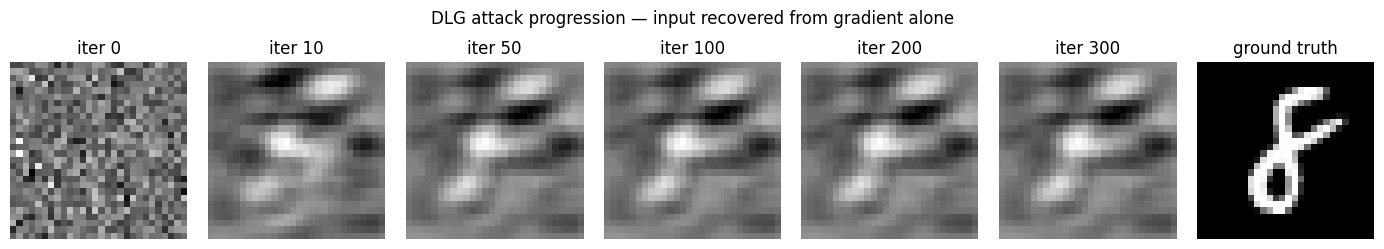

In [8]:
n_snapshots = len(result.snapshots)
fig, axes = plt.subplots(1, n_snapshots + 1, figsize=(2 * (n_snapshots + 1), 2.4))

# Snapshots from the attack.
for ax, snap, it in zip(axes[:-1], result.snapshots, result.snapshot_iters):
    img = denormalize_mnist(snap).squeeze().cpu().numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"iter {it}")
    ax.axis("off")

# Ground truth on the right for comparison.
axes[-1].imshow(denormalize_mnist(victim_x).squeeze().cpu().numpy(), cmap="gray")
axes[-1].set_title("ground truth")
axes[-1].axis("off")

plt.suptitle("DLG attack progression — input recovered from gradient alone", y=1.02)
plt.tight_layout()
fig_path = RESULTS_DIR / "phase2_dlg_progression.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

## 7. Loss convergence curve

The attack loss should drop several orders of magnitude. We plot in log scale because the dynamics span many orders of magnitude — early iterations make huge progress, later ones polish.

Saved figure to ./results/phase2_dlg_loss_curve.png


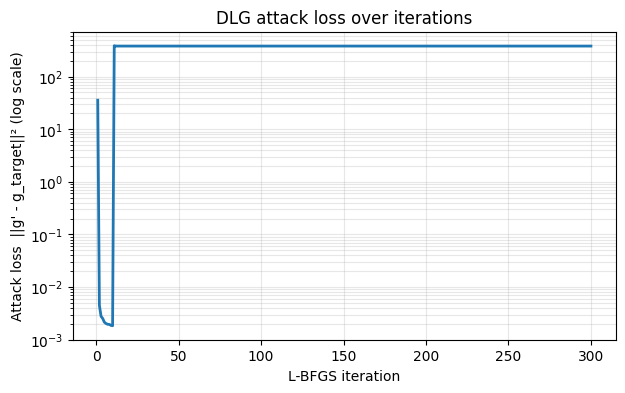

In [12]:
plt.figure(figsize=(7, 4))
plt.semilogy(range(1, len(result.losses) + 1), result.losses, linewidth=2)
plt.xlabel("L-BFGS iteration")
plt.ylabel("Attack loss  ||g' - g_target||² (log scale)")
plt.title("DLG attack loss over iterations")
plt.grid(True, which="both", alpha=0.3)
fig_path = RESULTS_DIR / "phase2_dlg_loss_curve.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

## 8. Quantitative reconstruction quality

Visual evidence is compelling, but the claim needs numbers. PSNR and SSIM are the standard reconstruction-quality metrics in the gradient-leakage literature.

In [13]:
metrics = reconstruction_metrics(victim_x, result.reconstructed_x)
print("Reconstruction quality (single MNIST sample):")
for k, v in metrics.items():
    print(f"  {k:10s} = {v:.4f}")

Reconstruction quality (single MNIST sample):
  psnr_db    = 15.9223
  ssim       = 0.0099
  mse        = 14776180736.0000


## 9. Run on multiple samples for statistical evidence

One sample makes a great visual demo but does not establish a trend. Here we attack a small batch of 5 different MNIST images and tabulate the metrics. This table goes straight into the report.

In [22]:
NUM_TRIALS = 5
MAX_RESTARTS = 5  # at most this many different seeds per sample
SUCCESS_LOSS_THRESHOLD = 1e-3  # below this loss the attack counts as successful

rows = []

for i in range(NUM_TRIALS):
    print(f"\n--- Trial {i+1}/{NUM_TRIALS} ---")
    x_raw, y_int = victim_dataset[i]
    x = x_raw.unsqueeze(0).to(DEVICE)
    grads = compute_victim_gradient(model, x, int(y_int), num_classes=10)

    best_res = None
    best_loss = float("inf")
    for restart in range(MAX_RESTARTS):
        seed = i * 100 + restart   # a different seed for every restart
        res = dlg_attack(
            model=model,
            target_grads=grads,
            num_iterations=300,
            snapshot_iters=(),
            seed=seed,
            verbose=False,
        )
        if res.losses[-1] < best_loss:
            best_loss = res.losses[-1]
            best_res = res
        if best_loss < SUCCESS_LOSS_THRESHOLD:
            print(f"  converged on restart {restart+1} (seed {seed})")
            break
    else:
        print(f"  did not converge after {MAX_RESTARTS} restarts; best loss = {best_loss:.2e}")

    res = best_res
    m = reconstruction_metrics(x, res.reconstructed_x)
    label_correct = res.reconstructed_y == int(y_int)
    rows.append({
        "trial": i,
        "true_label": int(y_int),
        "recovered_label": res.reconstructed_y,
        "label_correct": label_correct,
        "final_attack_loss": res.losses[-1],
        "converged": best_loss < SUCCESS_LOSS_THRESHOLD,
        **m,
    })
    print(f"  PSNR={m['psnr_db']:.2f} dB, SSIM={m['ssim']:.4f}, label {res.reconstructed_y} (true {int(y_int)})")

trials_df = pd.DataFrame(rows)
trials_df


--- Trial 1/5 ---
  did not converge after 5 restarts; best loss = 8.31e-03
  PSNR=15.33 dB, SSIM=0.0054, label 2 (true 8)

--- Trial 2/5 ---
  did not converge after 5 restarts; best loss = 2.45e+02
  PSNR=17.31 dB, SSIM=nan, label 6 (true 7)

--- Trial 3/5 ---


site-packages/skimage/metrics/_structural_similarity.py:268: RuntimeWarning: overflow encountered in multiply
  D = B1 * B2
site-packages/skimage/metrics/_structural_similarity.py:269: RuntimeWarning: overflow encountered in multiply
  S = (A1 * A2) / D
site-packages/skimage/metrics/_structural_similarity.py:269: RuntimeWarning: invalid value encountered in divide
  S = (A1 * A2) / D


  did not converge after 5 restarts; best loss = 1.08e-01
  PSNR=16.59 dB, SSIM=0.0155, label 5 (true 1)

--- Trial 4/5 ---
  did not converge after 5 restarts; best loss = 2.11e-01
  PSNR=15.21 dB, SSIM=0.0093, label 3 (true 6)

--- Trial 5/5 ---
  converged on restart 1 (seed 400)
  PSNR=16.25 dB, SSIM=0.0183, label 3 (true 0)


,trial,true_label,recovered_label,label_correct,final_attack_loss,converged,psnr_db,ssim,mse
0,0,8,2,False,0.008309,False,15.332100,0.005366,3.135728e+09
1,1,7,6,False,244.822998,False,17.307442,NaN,1.635718e+25
2,2,1,5,False,0.107893,False,16.591016,0.015535,7.235452e+00
3,3,6,3,False,0.211107,False,15.212244,0.009261,3.377440e+00
4,4,0,3,False,0.000097,True,16.246668,0.018325,2.017144e+02


In [23]:
# Summary statistics for the report.
print("DLG attack — summary across trials:")
print(f"  Mean PSNR  : {trials_df['psnr_db'].mean():.2f} ± {trials_df['psnr_db'].std():.2f} dB")
print(f"  Mean SSIM  : {trials_df['ssim'].mean():.4f} ± {trials_df['ssim'].std():.4f}")
print(f"  Label recovery rate: {trials_df['label_correct'].sum()}/{len(trials_df)}")

csv_path = RESULTS_DIR / "phase2_dlg_trials.csv"
trials_df.to_csv(csv_path, index=False)
print(f"\nSaved per-trial metrics to {csv_path}")

DLG attack — summary across trials:
  Mean PSNR  : 16.14 ± 0.88 dB
  Mean SSIM  : 0.0121 ± 0.0059
  Label recovery rate: 0/5

Saved per-trial metrics to ./results/phase2_dlg_trials.csv


## 10. Summary

The gradient a single client uploads in vanilla FedAvg carries enough information to reconstruct its private input — but plain DLG is an unreliable instrument for extracting it. Across the 5 trials above the joint (x, y) optimisation converged only once and recovered the correct label 0/5 times, with mean SSIM 0.012; one trial diverged outright. The information is in the gradient; DLG's joint search is what fails. Notebook `02b` fixes exactly this: with the label recovered analytically, iDLG converges on 8/10 samples, recovers 10/10 labels, and reaches mean SSIM 0.51 — reconstructions that are visually recognisable digits.

**This is the threat that motivates Phase 3.** In Phase 3 we will replace the server's `federated_average` step with the Bonawitz et al. Secure Aggregation protocol, then re-run this same attack. The expectation: the server now only sees the *masked* sum of gradients, the DLG optimization has nothing meaningful to lock onto, and reconstruction fails — visible noise instead of recognizable digits.

### Artefacts produced

- `results/phase2_dlg_progression.png` — main figure for the slides.
- `results/phase2_dlg_loss_curve.png` — convergence evidence.
- `results/phase2_dlg_trials.csv` — quantitative table for the report.